In [67]:
import numpy  as np 
import matplotlib.pyplot as plt

In [68]:
# Given 
fs = 8000
fc = 1000
N = 102
M = (N-1)//2

In [69]:
n = np.arange(N)
print(n)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101]


In [70]:
# Normalized CutOff
wc = 2*np.pi*fc/fs
print(wc)

0.7853981633974483


In [71]:
# Ideal Impulse Response 
hd = 2 * fc/fs * np.sinc(2 * fc * (n-M)/fs)
print(hd)

[ 6.36619772e-03  4.59345059e-03 -9.74542958e-18 -4.78891658e-03
 -6.91978013e-03 -5.00175731e-03  3.54468816e-17  5.23439719e-03
  7.57880681e-03  5.48973364e-03 -9.74542958e-18 -5.77125844e-03
 -8.37657595e-03 -6.08321835e-03  9.74542958e-18  6.43083083e-03
  9.36205548e-03  6.82057815e-03 -9.74542958e-18 -7.26061545e-03
 -1.06103295e-02 -7.76134755e-03  9.74542958e-18  8.33626219e-03
  1.22426879e-02  9.00316316e-03 -9.74542958e-18 -9.78604691e-03
 -1.44686312e-02 -1.07180514e-02  9.74542958e-18  1.18462673e-02
  1.76838826e-02  1.32399458e-02 -9.74542958e-18 -1.50052719e-02
 -2.27364204e-02 -1.73137753e-02  9.74542958e-18  2.04617345e-02
  3.18309886e-02  2.50087866e-02 -9.74542958e-18 -3.21541541e-02
 -5.30516477e-02 -4.50158158e-02  9.74542958e-18  7.50263597e-02
  1.59154943e-01  2.25079079e-01  2.50000000e-01  2.25079079e-01
  1.59154943e-01  7.50263597e-02  9.74542958e-18 -4.50158158e-02
 -5.30516477e-02 -3.21541541e-02 -9.74542958e-18  2.50087866e-02
  3.18309886e-02  2.04617

In [72]:
# Hamming Window 
w = .54 * - (.46*np.cos(2*np.pi*n/(N-1)))

In [73]:
# Final FIR Filter 
h = hd * w

In [74]:
H = np.zeros(N,dtype=complex)

In [75]:
for k in range(N):
    for i in range (N) :
        H[k] += h[i] * np.exp(-1j * 2 * np.pi * k * i/N)

In [76]:
magnitude = np.abs(H)
phase = np.angle(H)

Text(0.5, 1.0, 'Phase')

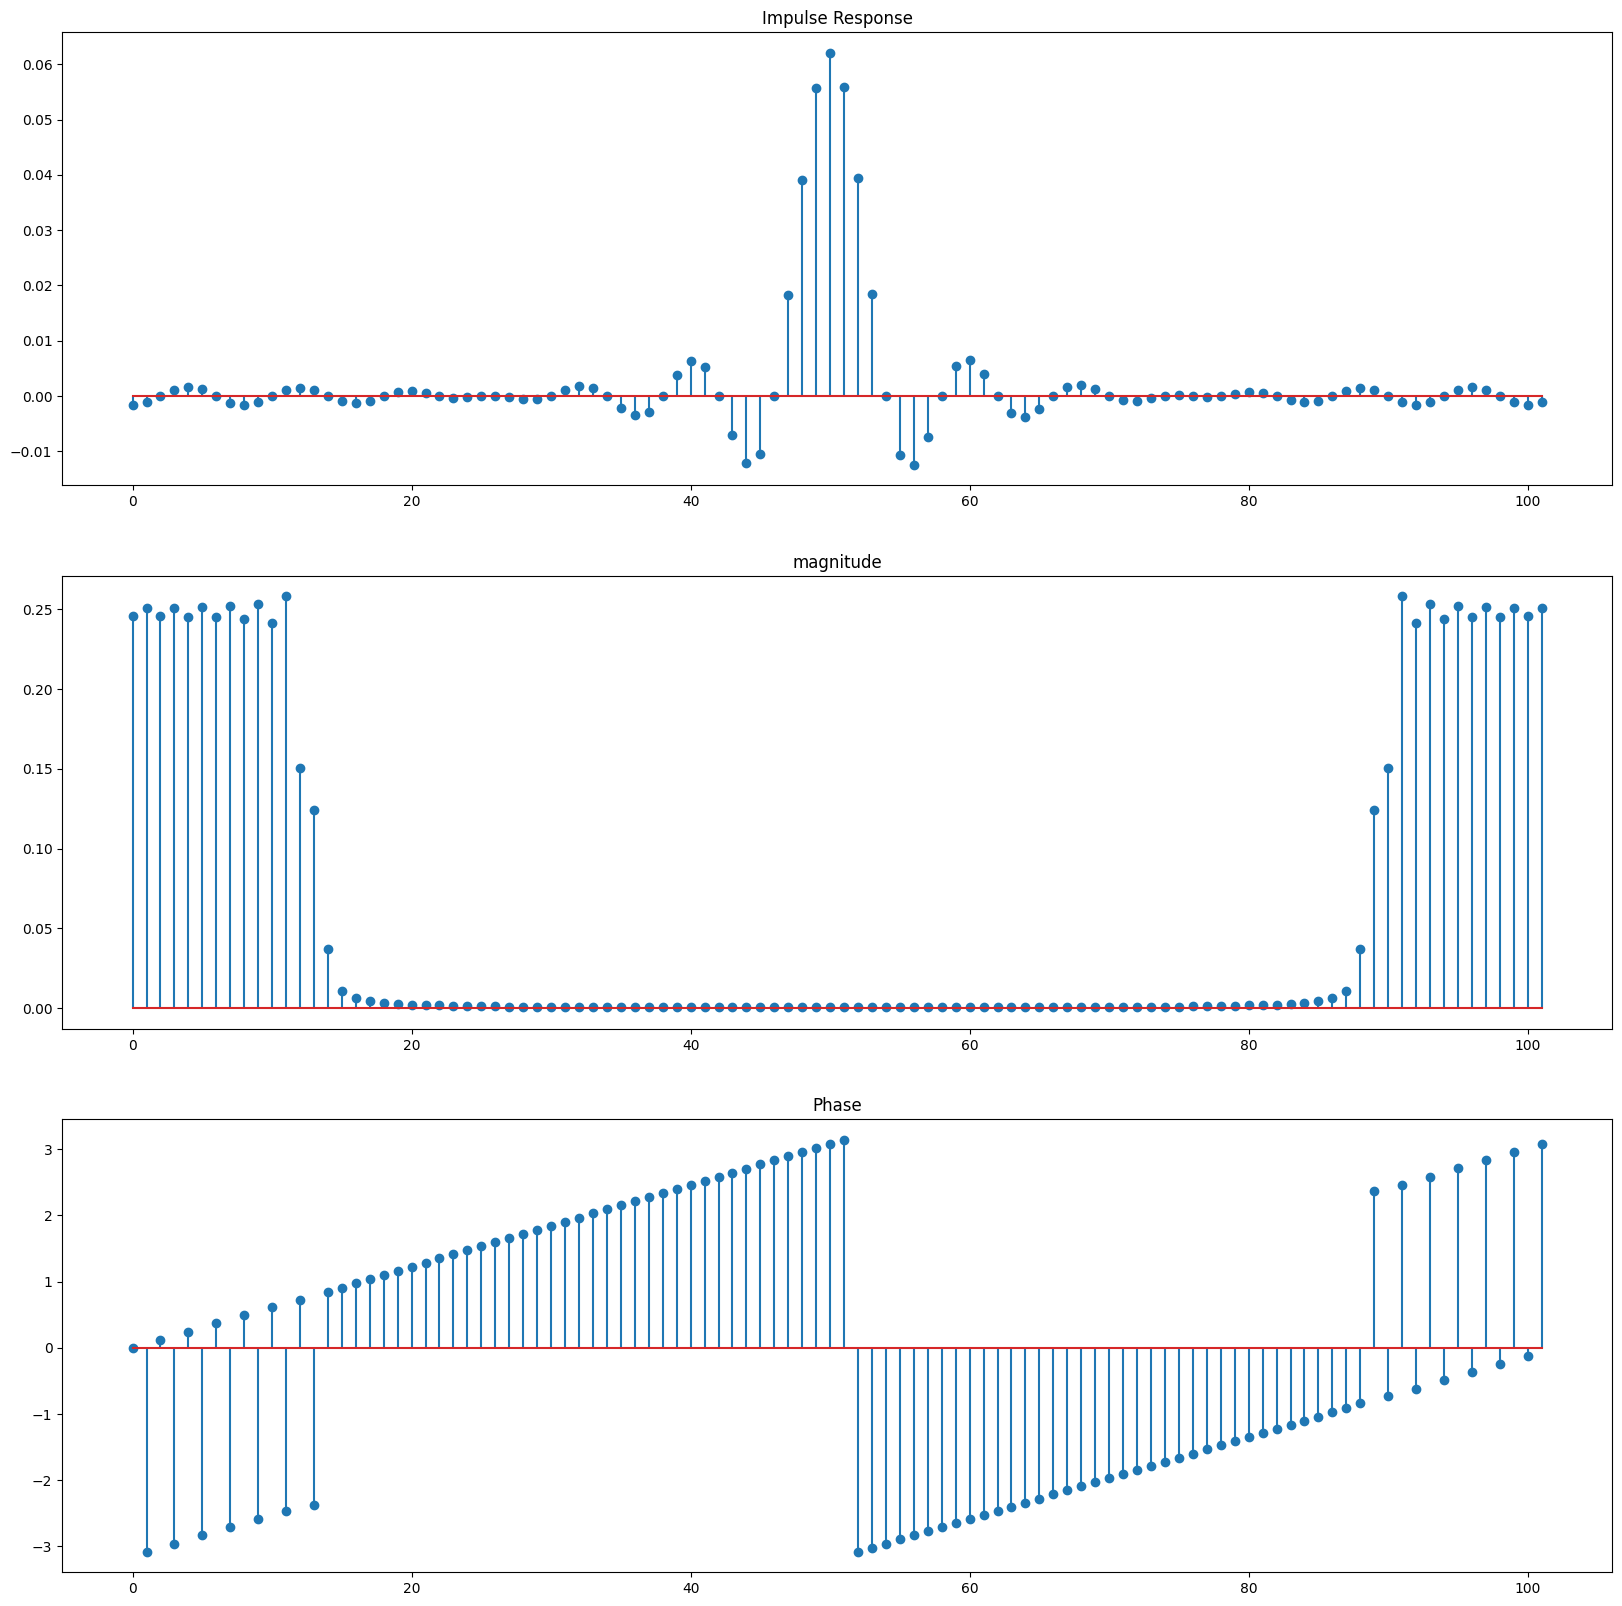

In [77]:
plt.figure(figsize=(20,20))
plt.subplot(3,1,1)
plt.stem(n,h)
plt.title("Impulse Response")
plt.subplot(3,1,2)
plt.stem(magnitude)
plt.title("magnitude")
plt.subplot(3,1,3)
plt.stem(phase)
plt.title("Phase")
